# Pokemon Image Classification - Exploratory Data Analysis

This notebook analyzes the Pokemon image dataset to evaluate data readiness for multi-class classification, with emphasis on class imbalance, data quality, and split reliability.

### EDA Flow
1. **Data Ingestion** - index image files and build metadata.
2. **Distribution Analysis** - inspect dataset scale and class imbalance.
3. **Image Property Analysis** - study geometry, format, and visual statistics.
4. **Data Quality Analysis** - detect corruption and duplicate risks.
5. **Split Readiness Analysis** - simulate train/val/test and audit coverage/leakage.

In [45]:
from pathlib import Path
import hashlib
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")

CHART_COLORS = {
    "primary": "#2563EB",
    "secondary": "#0EA5E9",
    "accent": "#14B8A6",
    "warning": "#F59E0B",
    "danger": "#EF4444",
    "neutral": "#334155",
    "background": "#F8FAFC",
}


def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=CHART_COLORS["neutral"], pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_facecolor(CHART_COLORS["background"])
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)


plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = "../../../datasets/pokemon/data/images"

## 1. Build Metadata Table

Index all image files and construct a base metadata table used by later analyses.

Expected core fields:
- `class_name`: label from folder name
- `file_path`: full path to image file
- `ext`: file extension
- `file_size_kb`: file size in kilobytes

In [46]:
image_paths = sorted([p for p in Path(DATA_PATH).rglob("*") if p.is_file()])

records = []
for p in tqdm(image_paths, desc="Indexing image files"):
    records.append(
        {
            "class_name": p.parent.name,
            "file_path": str(p),
            "ext": p.suffix.lower(),
            "file_size_kb": p.stat().st_size / 1024,
        }
    )

df = pd.DataFrame(records)
class_stats = (
    df.groupby("class_name", as_index=False)
    .agg(
        image_count=("file_path", "size"),
        mean_file_size_kb=("file_size_kb", "mean"),
    )
    .sort_values("image_count", ascending=False)
)

print(f"Total images: {len(df):,}")
print(f"Total classes: {class_stats.shape[0]:,}")
print("\nTop 10 classes by image count:")
display(class_stats.head(10))

Indexing image files:   0%|          | 0/2503 [00:00<?, ?it/s]

Total images: 2,503
Total classes: 898

Top 10 classes by image count:


,class_name,image_count,mean_file_size_kb
835,Venusaur,8,36.067383
520,Necrozma,7,19.685547
5,Aerodactyl,6,17.616862
824,Unown,6,10.789225
844,Vivillon,6,24.463867
384,Kangaskhan,6,31.643717
897,Zygarde,6,26.970866
51,Beedrill,6,29.613444
314,Graveler,6,19.747233
317,Grimer,6,25.282552


### 1.1 Sample Metadata Records

In [47]:
display(df.sample(n=min(5, len(df)), random_state=SEED))

,class_name,file_path,ext,file_size_kb
582,Eiscue,../../../datasets/pokemon/data/images/Eiscue/0...,.jpg,19.940430
1131,Lapras,../../../datasets/pokemon/data/images/Lapras/3...,.jpg,33.022461
1591,Phione,../../../datasets/pokemon/data/images/Phione/1...,.jpg,12.383789
1419,Mudbray,../../../datasets/pokemon/data/images/Mudbray/...,.jpg,14.716797
1754,Rayquaza,../../../datasets/pokemon/data/images/Rayquaza...,.jpg,32.387695


## 2. Dataset Overview and Class Imbalance

Report global dataset scale and diagnose long-tail behavior across class labels.

In [48]:
images_per_class = class_stats["image_count"]
summary = pd.DataFrame(
    {
        "metric": [
            "Total images",
            "Total classes",
            "Avg images/class",
            "Median images/class",
            "Min images/class",
            "Max images/class",
            "Classes with 1 image",
            "Classes with <=2 images",
        ],
        "value": [
            int(len(df)),
            int(class_stats.shape[0]),
            round(images_per_class.mean(), 2),
            int(images_per_class.median()),
            int(images_per_class.min()),
            int(images_per_class.max()),
            int((images_per_class == 1).sum()),
            int((images_per_class <= 2).sum()),
        ],
    }
)

display(summary)

,metric,value
0,Total images,2503.00
1,Total classes,898.00
2,Avg images/class,2.79
3,Median images/class,2.00
4,Min images/class,1.00
5,Max images/class,8.00
6,Classes with 1 image,54.00
7,Classes with <=2 images,520.00


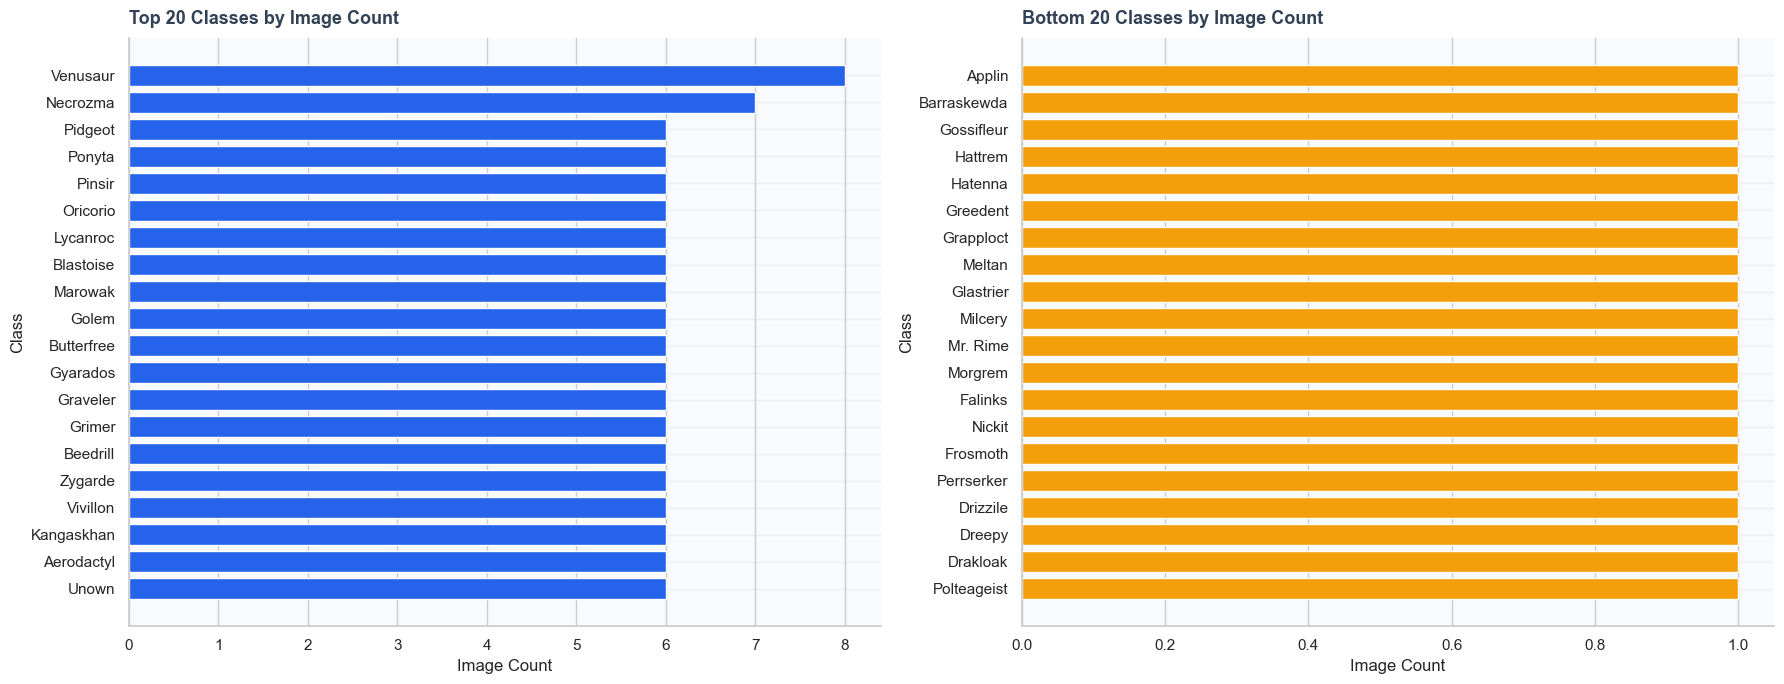

In [49]:
top_k = 20
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_classes = class_stats.head(top_k).sort_values("image_count")
bottom_classes = class_stats.tail(top_k).sort_values("image_count")

axes[0].barh(top_classes["class_name"], top_classes["image_count"], color=CHART_COLORS["primary"])
style_ax(axes[0], f"Top {top_k} Classes by Image Count", "Image Count", "Class")

axes[1].barh(bottom_classes["class_name"], bottom_classes["image_count"], color=CHART_COLORS["warning"])
style_ax(axes[1], f"Bottom {top_k} Classes by Image Count", "Image Count", "Class")

plt.tight_layout()
plt.show()

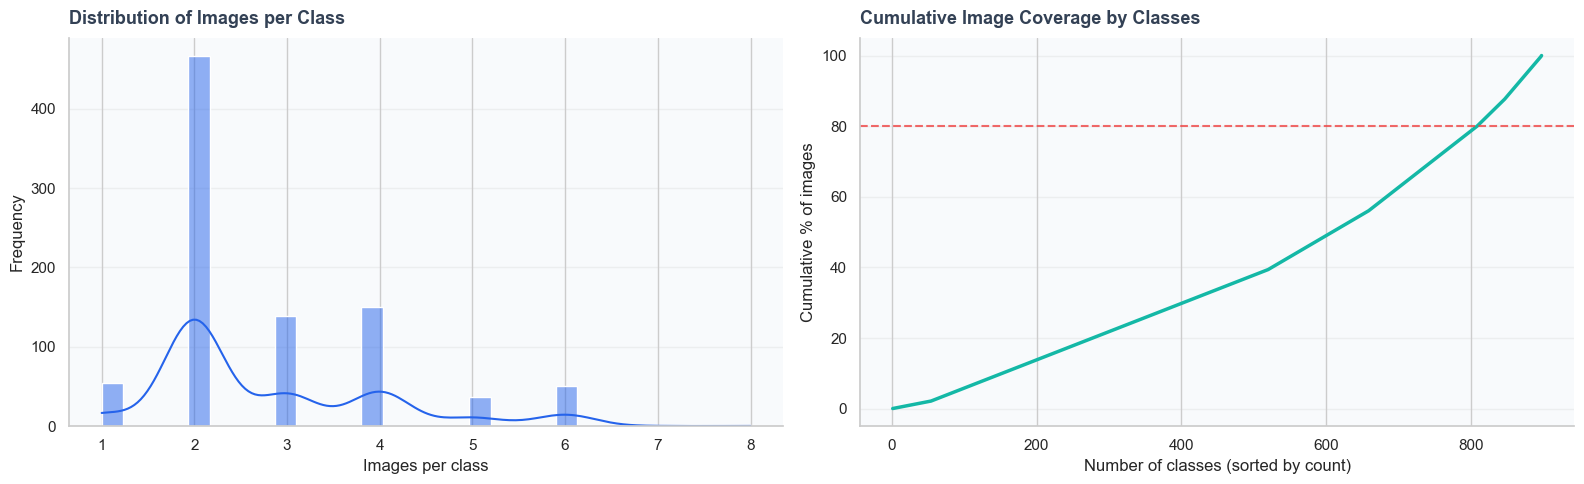

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(images_per_class, bins=30, kde=True, ax=axes[0], color=CHART_COLORS["primary"])
style_ax(axes[0], "Distribution of Images per Class", "Images per class", "Frequency")

sorted_counts = np.sort(images_per_class.values)
cum_pct = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
axes[1].plot(np.arange(1, len(sorted_counts) + 1), cum_pct, color=CHART_COLORS["accent"], lw=2.5)
axes[1].axhline(80, color=CHART_COLORS["danger"], linestyle="--", alpha=0.8)
style_ax(axes[1], "Cumulative Image Coverage by Classes", "Number of classes", "Cumulative % of images")

plt.tight_layout()
plt.show()

## 3. Image Properties

Analyze geometric and visual properties that may affect preprocessing and model stability.

In [51]:
meta_records = []
bad_files = []

for fp in tqdm(df["file_path"], desc="Reading image metadata"):
    try:
        with Image.open(fp) as img:
            width, height = img.size
            mode = img.mode
            arr = np.asarray(img.convert("RGB"), dtype=np.float32)
            mean_rgb = arr.reshape(-1, 3).mean(axis=0)
            brightness = arr.mean()
            contrast = arr.std()

        meta_records.append(
            {
                "file_path": fp,
                "width": width,
                "height": height,
                "mode": mode,
                "mean_r": float(mean_rgb[0]),
                "mean_g": float(mean_rgb[1]),
                "mean_b": float(mean_rgb[2]),
                "brightness": float(brightness),
                "contrast": float(contrast),
            }
        )
    except (UnidentifiedImageError, OSError, ValueError) as err:
        bad_files.append((fp, str(err)))

meta_df = pd.DataFrame(meta_records)
df = df.merge(meta_df, on="file_path", how="left")

df["aspect_ratio"] = df["width"] / df["height"]
df["megapixels"] = (df["width"] * df["height"]) / 1_000_000

print(f"Valid images: {meta_df.shape[0]:,}")
print(f"Unreadable/corrupted images: {len(bad_files):,}")

Reading image metadata:   0%|          | 0/2503 [00:00<?, ?it/s]

Valid images: 2,503
Unreadable/corrupted images: 0


### 3.1 Missing Values Audit

In [52]:
critical_cols = [
    "class_name",
    "file_path",
    "ext",
    "file_size_kb",
    "width",
    "height",
    "mode",
    "brightness",
    "contrast",
    "aspect_ratio",
    "megapixels",
]

missing_report = (
    df[critical_cols]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_report["missing_pct"] = (missing_report["missing_count"] / len(df) * 100).round(2)

rows_with_missing = int(df[critical_cols].isna().any(axis=1).sum())

print("Missing-values report for critical columns:")
display(missing_report)
print(f"Rows containing any missing value in critical columns: {rows_with_missing:,}")

Missing-values report for critical columns:


,missing_count,missing_pct
class_name,0,0.0
file_path,0,0.0
ext,0,0.0
file_size_kb,0,0.0
width,0,0.0
height,0,0.0
mode,0,0.0
brightness,0,0.0
contrast,0,0.0
aspect_ratio,0,0.0


Rows containing any missing value in critical columns: 0


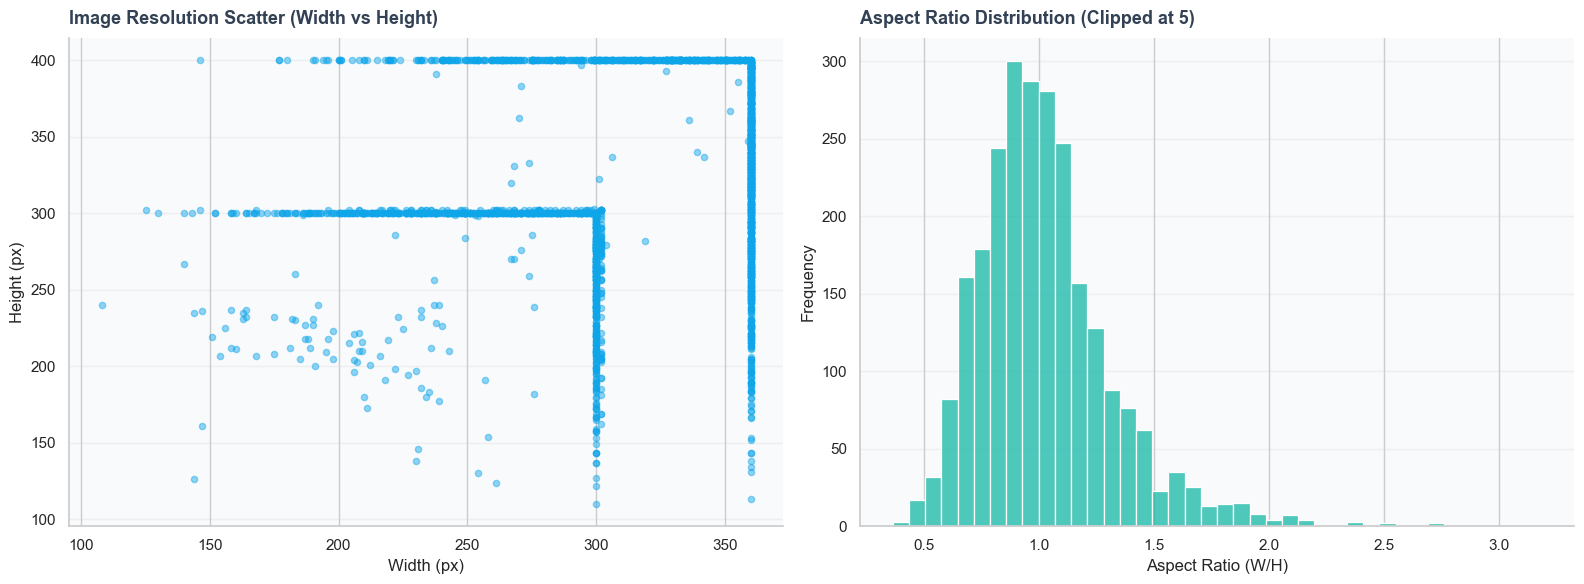

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df["width"], df["height"], s=20, alpha=0.45, c=CHART_COLORS["secondary"])
style_ax(axes[0], "Image Resolution Scatter (Width vs Height)", "Width (px)", "Height (px)")

sns.histplot(df["aspect_ratio"].clip(upper=5), bins=40, ax=axes[1], color=CHART_COLORS["accent"])
style_ax(axes[1], "Aspect Ratio Distribution (Clipped at 5)", "Aspect Ratio (W/H)", "Frequency")

plt.tight_layout()
plt.show()

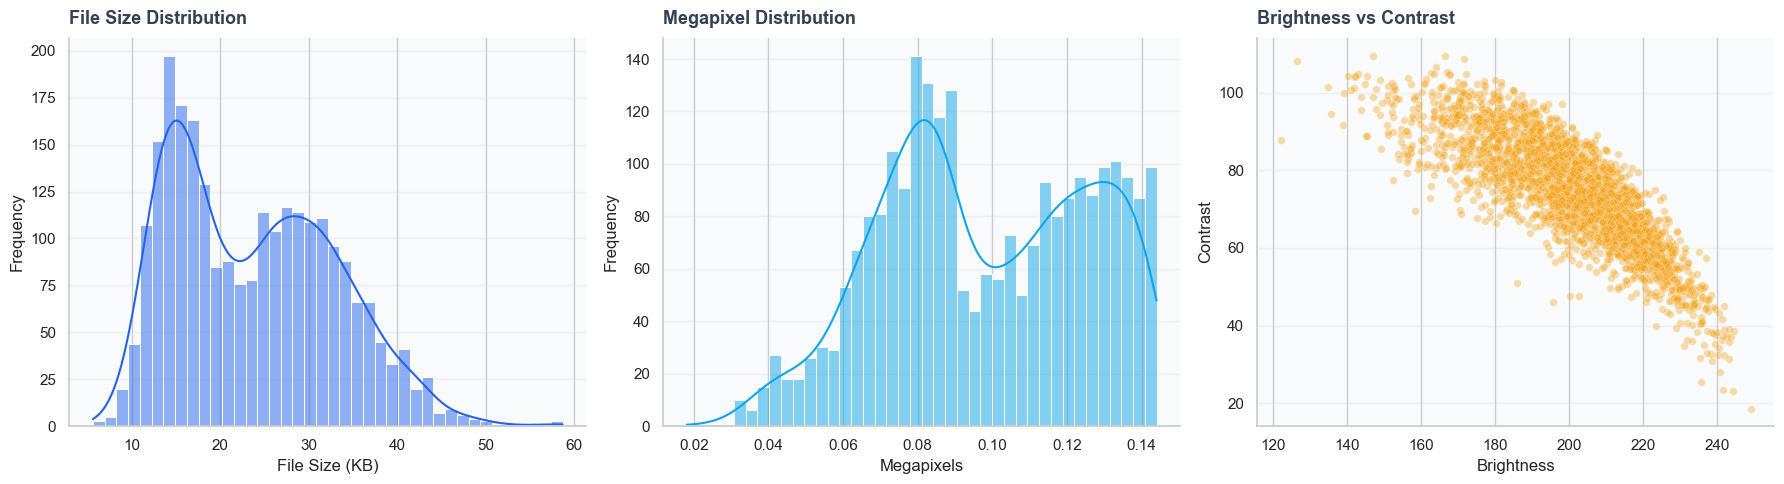

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["file_size_kb"], bins=40, kde=True, ax=axes[0], color=CHART_COLORS["primary"])
style_ax(axes[0], "File Size Distribution", "File Size (KB)", "Frequency")

sns.histplot(df["megapixels"], bins=40, kde=True, ax=axes[1], color=CHART_COLORS["secondary"])
style_ax(axes[1], "Megapixel Distribution", "Megapixels", "Frequency")

sns.scatterplot(data=df, x="brightness", y="contrast", alpha=0.35, s=30, ax=axes[2], color=CHART_COLORS["warning"])
style_ax(axes[2], "Brightness vs Contrast", "Brightness", "Contrast")

plt.tight_layout()
plt.show()

### 3.2 File Format, Color Mode, and Outliers

File extension distribution:


,ext,count,pct
0,.jpg,2503,100.0



Color mode distribution:


,mode,count,pct
0,RGB,2503,100.0



Outlier rate (IQR rule):


,pct_outliers
file_size_outlier,0.16
megapixel_outlier,0.00
aspect_ratio_outlier,3.84


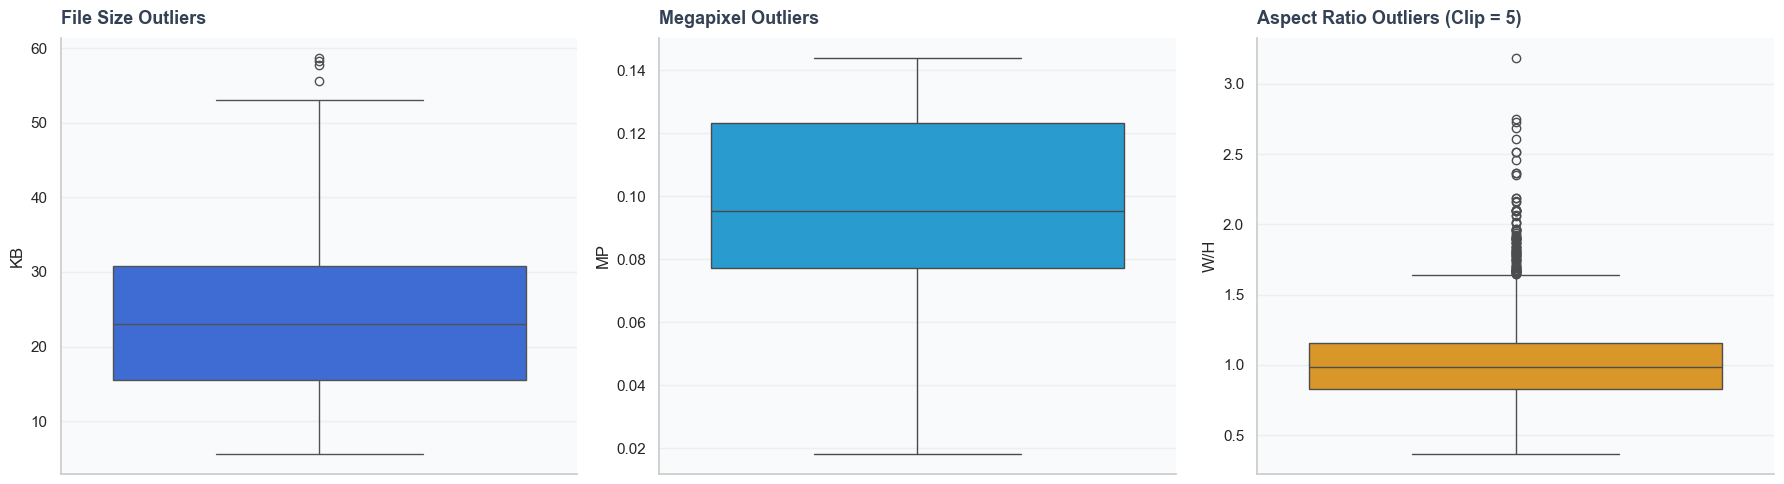

In [55]:
format_dist = df["ext"].value_counts(dropna=False).rename_axis("ext").reset_index(name="count")
format_dist["pct"] = (format_dist["count"] / len(df) * 100).round(2)

mode_dist = (
    df["mode"].fillna("UNKNOWN").value_counts().rename_axis("mode").reset_index(name="count")
)
mode_dist["pct"] = (mode_dist["count"] / len(df) * 100).round(2)

print("File extension distribution:")
display(format_dist)
print("\nColor mode distribution:")
display(mode_dist)

def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_flags = pd.DataFrame(
    {
        "file_size_outlier": iqr_outlier_mask(df["file_size_kb"]),
        "megapixel_outlier": iqr_outlier_mask(df["megapixels"]),
        "aspect_ratio_outlier": iqr_outlier_mask(df["aspect_ratio"]),
    }
)

outlier_summary = outlier_flags.mean().mul(100).round(2).rename("pct_outliers").to_frame()
print("\nOutlier rate (IQR rule):")
display(outlier_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df["file_size_kb"], ax=axes[0], color=CHART_COLORS["primary"])
style_ax(axes[0], "File Size Outliers", None, "KB")

sns.boxplot(y=df["megapixels"], ax=axes[1], color=CHART_COLORS["secondary"])
style_ax(axes[1], "Megapixel Outliers", None, "MP")

sns.boxplot(y=df["aspect_ratio"].clip(upper=5), ax=axes[2], color=CHART_COLORS["warning"])
style_ax(axes[2], "Aspect Ratio Outliers (Clip = 5)", None, "W/H")

plt.tight_layout()
plt.show()

## 4. Color Space and Class-Level Descriptive Statistics

In [70]:
import plotly.express as px

sample_for_color = df.dropna(subset=["mean_r", "mean_g", "mean_b", "brightness"]).sample(
    n=min(700, len(df)), random_state=SEED
)

fig = px.scatter_3d(
    sample_for_color,
    x="mean_r",
    y="mean_g",
    z="mean_b",
    color="brightness",
    color_continuous_scale="Viridis",
    opacity=0.72,
    title="Color Space Distribution (RGB)",
    labels={
        "mean_r": "Red",
        "mean_g": "Green",
        "mean_b": "Blue",
        "brightness": "Brightness",
    },
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    template="plotly_white",
    height=620,
    margin=dict(l=10, r=10, t=70, b=10),
    coloraxis_colorbar=dict(title="Brightness"),
    scene=dict(
        xaxis=dict(range=[0, 255], backgroundcolor="rgba(238, 244, 252, 0.85)", gridcolor="white"),
        yaxis=dict(range=[0, 255], backgroundcolor="rgba(238, 244, 252, 0.85)", gridcolor="white"),
        zaxis=dict(range=[0, 255], backgroundcolor="rgba(238, 244, 252, 0.85)", gridcolor="white"),
        camera=dict(eye=dict(x=1.35, y=1.2, z=0.9)),
    ),
)

fig.show()

In [57]:
class_enriched = (
    df.groupby("class_name", as_index=False)
    .agg(
        image_count=("file_path", "size"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        avg_brightness=("brightness", "mean"),
        avg_contrast=("contrast", "mean"),
    )
    .sort_values("image_count", ascending=False)
)

display(class_enriched.head(12))

,class_name,image_count,avg_width,avg_height,avg_brightness,avg_contrast
835,Venusaur,8,345.000000,272.000000,175.677088,82.050406
520,Necrozma,7,326.857143,268.000000,203.396279,79.612628
5,Aerodactyl,6,340.000000,261.000000,223.231295,58.162631
824,Unown,6,221.166667,311.166667,177.437335,90.357014
844,Vivillon,6,312.000000,293.833333,173.862055,93.436399
384,Kangaskhan,6,338.166667,342.166667,199.302905,67.239113
897,Zygarde,6,334.333333,328.833333,173.915642,91.883509
51,Beedrill,6,329.666667,336.833333,217.222415,69.414825
314,Graveler,6,340.333333,204.833333,196.893262,69.945166
317,Grimer,6,340.333333,305.333333,187.678383,73.808500


## 5. Data Quality Checks

In [58]:
if bad_files:
    bad_df = pd.DataFrame(bad_files, columns=["file_path", "error"])
    print(f"Unreadable files found: {len(bad_df)}")
    display(bad_df.head(10))
else:
    print("No corrupted/unreadable files were found.")

No corrupted/unreadable files were found.


In [59]:
def file_md5(path_str: str, chunk_size: int = 8192) -> str:
    h = hashlib.md5()
    with open(path_str, "rb") as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()

hash_sample = df["file_path"].tolist()
md5_values = [file_md5(fp) for fp in tqdm(hash_sample, desc="Computing MD5")]
hash_df = pd.DataFrame({"file_path": hash_sample, "md5": md5_values})

dup_groups = (
    hash_df.groupby("md5")
    .agg(duplicate_count=("file_path", "size"), examples=("file_path", lambda x: list(x)[:3]))
    .query("duplicate_count > 1")
    .sort_values("duplicate_count", ascending=False)
)

print(f"Duplicate hash groups: {len(dup_groups):,}")
display(dup_groups.head(10))

Computing MD5:   0%|          | 0/2503 [00:00<?, ?it/s]

Duplicate hash groups: 1


,duplicate_count,examples
md5,,
ef91ef54c5a547fac16241775d4e2f29,2,[../../../datasets/pokemon/data/images/Appletu...


### 5.1 Duplicate Types: Within-Class vs Cross-Class

In [60]:
dup_detail = hash_df.merge(df[["file_path", "class_name"]], on="file_path", how="left")
dup_stats = dup_detail.groupby("md5").agg(
    duplicate_count=("file_path", "size"),
    unique_classes=("class_name", "nunique"),
)

dup_stats = dup_stats.query("duplicate_count > 1").copy()

if dup_stats.empty:
    print("No duplicate groups were found.")
else:
    within_class_groups = int((dup_stats["unique_classes"] == 1).sum())
    cross_class_groups = int((dup_stats["unique_classes"] > 1).sum())

    print(f"Duplicate groups (total): {len(dup_stats):,}")
    print(f"Within-class duplicate groups: {within_class_groups:,}")
    print(f"Cross-class duplicate groups: {cross_class_groups:,}")

    span_summary = (
        dup_stats["unique_classes"]
        .value_counts()
        .sort_index()
        .rename_axis("num_classes_in_group")
        .reset_index(name="num_groups")
    )
    display(span_summary)

    risky_md5 = dup_stats[dup_stats["unique_classes"] > 1].index
    if len(risky_md5) > 0:
        cross_class_examples = (
            dup_detail[dup_detail["md5"].isin(risky_md5)]
            .groupby("md5")
            .agg(
                classes=("class_name", lambda x: sorted(set(x))),
                sample_files=("file_path", lambda x: list(x)[:3]),
            )
            .head(10)
        )
        print("Examples of cross-class duplicate groups:")
        display(cross_class_examples)

Duplicate groups (total): 1
Within-class duplicate groups: 0
Cross-class duplicate groups: 1


,num_classes_in_group,num_groups
0,2,1


Examples of cross-class duplicate groups:


,classes,sample_files
md5,,
ef91ef54c5a547fac16241775d4e2f29,"[Appletun, Flapple]",[../../../datasets/pokemon/data/images/Appletu...


### 5.2 Duplicate Impact on Training Data

Quantify how many images are affected by exact duplicates and identify classes where duplicate pressure is highest.

In [61]:
dup_file_counts = hash_df["md5"].value_counts()
dup_groups_count = int((dup_file_counts > 1).sum())
dup_images_total = int(dup_file_counts[dup_file_counts > 1].sum())
dup_images_extra = int((dup_file_counts[dup_file_counts > 1] - 1).sum())

duplicate_impact = pd.DataFrame(
    {
        "metric": [
            "Total images",
            "Duplicate hash groups",
            "Images in duplicate groups",
            "Redundant duplicate images (beyond first unique)",
            "Images in duplicate groups (%)",
            "Redundant duplicate images (%)",
        ],
        "value": [
            int(len(df)),
            dup_groups_count,
            dup_images_total,
            dup_images_extra,
            round(dup_images_total / len(df) * 100, 2),
            round(dup_images_extra / len(df) * 100, 2),
        ],
    }
)

display(duplicate_impact)

if dup_groups_count > 0:
    dup_affected = (
        hash_df.merge(df[["file_path", "class_name"]], on="file_path", how="left")
        .loc[lambda x: x["md5"].isin(dup_file_counts[dup_file_counts > 1].index)]
        .groupby("class_name")
        .size()
        .rename("duplicate_images")
        .reset_index()
    )
    class_size = df.groupby("class_name").size().rename("class_size")
    dup_affected = dup_affected.merge(class_size, on="class_name", how="left")
    dup_affected["pct_of_class"] = (dup_affected["duplicate_images"] / dup_affected["class_size"] * 100).round(2)
    dup_affected = dup_affected.sort_values(["pct_of_class", "duplicate_images"], ascending=False)

    print("Top classes affected by exact duplicates:")
    display(dup_affected.head(12))

,metric,value
0,Total images,2503.00
1,Duplicate hash groups,1.00
2,Images in duplicate groups,2.00
3,Redundant duplicate images (beyond first unique),1.00
4,Images in duplicate groups (%),0.08
5,Redundant duplicate images (%),0.04


Top classes affected by exact duplicates:


,class_name,duplicate_images,class_size,pct_of_class
0,Appletun,1,2,50.0
1,Flapple,1,2,50.0


## 6. Split Simulation for Classification (Train, Validation, Test)

In [62]:
def per_class_split(group: pd.DataFrame) -> pd.Series:
    idx = group.index.tolist()
    random.shuffle(idx)
    n = len(idx)

    if n == 1:
        split = ["test"]
    elif n == 2:
        split = ["train", "test"]
    elif n == 3:
        split = ["train", "train", "test"]
    else:
        n_train = max(1, int(round(n * 0.7)))
        n_val = max(1, int(round(n * 0.15)))
        n_test = n - n_train - n_val
        if n_test < 1:
            n_test = 1
            if n_train > n_val:
                n_train -= 1
            else:
                n_val -= 1
        split = ["train"] * n_train + ["val"] * n_val + ["test"] * n_test

    return pd.Series(split, index=idx)

split_col = df.groupby("class_name", group_keys=False).apply(per_class_split)
df["split"] = split_col.reindex(df.index)

split_summary = df["split"].value_counts().rename_axis("split").reset_index(name="count")
split_summary["pct"] = (split_summary["count"] / len(df) * 100).round(2)

display(split_summary)

,split,count,pct
0,train,1366,54.57
1,test,898,35.88
2,val,239,9.55


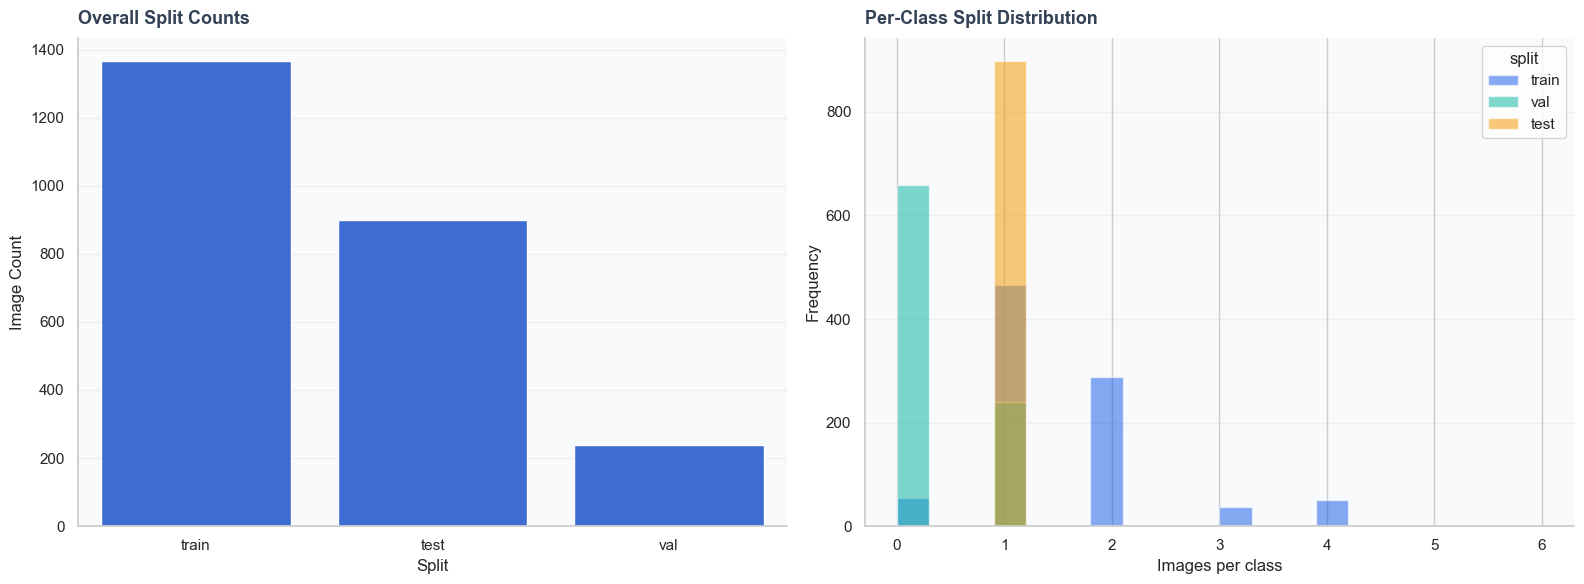

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=split_summary, x="split", y="count", color=CHART_COLORS["primary"], ax=axes[0])
style_ax(axes[0], "Overall Split Counts", "Split", "Image Count")

split_per_class = (
    df.pivot_table(index="class_name", columns="split", values="file_path", aggfunc="size", fill_value=0)
    .reset_index()
)

for col in ["train", "val", "test"]:
    if col not in split_per_class.columns:
        split_per_class[col] = 0

split_per_class[["train", "val", "test"]].plot(
    kind="hist",
    bins=20,
    alpha=0.55,
    ax=axes[1],
    color=[CHART_COLORS["primary"], CHART_COLORS["accent"], CHART_COLORS["warning"]],
)
style_ax(axes[1], "Per-Class Split Distribution", "Images per class", "Frequency")

plt.tight_layout()
plt.show()

### 6.1 Leakage Risk Check Using Duplicate Hashes

In [64]:
dup_split = hash_df.merge(df[["file_path", "split", "class_name"]], on="file_path", how="left")
dup_split_stats = dup_split.groupby("md5").agg(
    duplicate_count=("file_path", "size"),
    split_count=("split", "nunique"),
    class_count=("class_name", "nunique"),
)

dup_split_stats = dup_split_stats.query("duplicate_count > 1").copy()

if dup_split_stats.empty:
    print("No duplicate groups to evaluate for split leakage.")
else:
    leaking_groups = dup_split_stats[dup_split_stats["split_count"] > 1]
    leak_summary = pd.DataFrame(
        {
            "metric": [
                "Duplicate groups",
                "Leaking groups across >=2 splits",
                "Leakage rate among duplicate groups (%)",
            ],
            "value": [
                int(len(dup_split_stats)),
                int(len(leaking_groups)),
                round(len(leaking_groups) / len(dup_split_stats) * 100, 2),
            ],
        }
    )
    display(leak_summary)

    if not leaking_groups.empty:
        leak_examples = (
            dup_split[dup_split["md5"].isin(leaking_groups.index)]
            .sort_values(["md5", "split", "class_name"])
            .groupby("md5")
            .agg(
                splits=("split", lambda x: sorted(set(x))),
                classes=("class_name", lambda x: sorted(set(x))),
                sample_files=("file_path", lambda x: list(x)[:3]),
            )
            .head(10)
        )
        print("Examples of duplicate hashes spanning multiple splits:")
        display(leak_examples)

,metric,value
0,Duplicate groups,1.0
1,Leaking groups across >=2 splits,0.0
2,Leakage rate among duplicate groups (%),0.0


### 6.2 Split Coverage Audit by Class

Audit whether each class has sufficient train/validation/test representation under the current split simulation.

,metric,value
0,Total classes,898
1,Classes with no validation sample,659
2,Classes with no test sample,0
3,Classes with <=1 train sample,520


Classes with weakest split coverage:


split,class_name,total,train,val,test,missing_val,missing_test,tiny_train
18,Applin,1,0,0,1,True,False,True
25,Arctovish,1,0,0,1,True,False,True
26,Arctozolt,1,0,0,1,True,False,True
31,Arrokuda,1,0,0,1,True,False,True
45,Barraskewda,1,0,0,1,True,False,True
65,Blipbug,1,0,0,1,True,False,True
69,Boltund,1,0,0,1,True,False,True
93,Carkol,1,0,0,1,True,False,True
114,Chewtle,1,0,0,1,True,False,True
129,Clobbopus,1,0,0,1,True,False,True


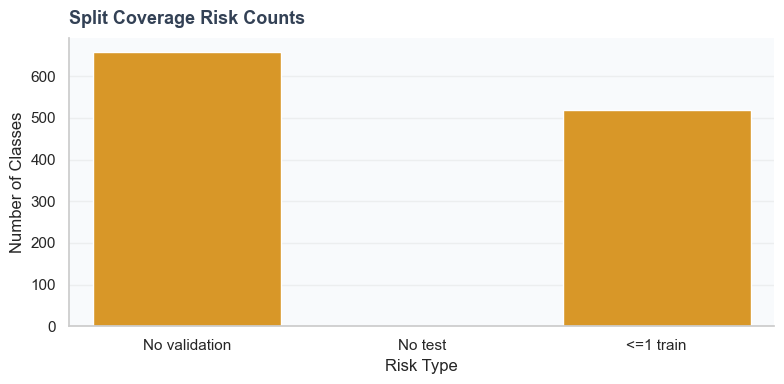

In [65]:
split_coverage = (
    df.pivot_table(index="class_name", columns="split", values="file_path", aggfunc="size", fill_value=0)
    .reset_index()
)
for col in ["train", "val", "test"]:
    if col not in split_coverage.columns:
        split_coverage[col] = 0

split_coverage["total"] = split_coverage[["train", "val", "test"]].sum(axis=1)
split_coverage["missing_val"] = split_coverage["val"] == 0
split_coverage["missing_test"] = split_coverage["test"] == 0
split_coverage["tiny_train"] = split_coverage["train"] <= 1

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "Total classes",
            "Classes with no validation sample",
            "Classes with no test sample",
            "Classes with <=1 train sample",
        ],
        "value": [
            int(split_coverage.shape[0]),
            int(split_coverage["missing_val"].sum()),
            int(split_coverage["missing_test"].sum()),
            int(split_coverage["tiny_train"].sum()),
        ],
    }
)

display(coverage_summary)

print("Classes with weakest split coverage:")
weakest_split = split_coverage.sort_values(["total", "train", "val", "test"]).head(15)
display(weakest_split[["class_name", "total", "train", "val", "test", "missing_val", "missing_test", "tiny_train"]])

issue_counts = pd.Series(
    {
        "No validation": int(split_coverage["missing_val"].sum()),
        "No test": int(split_coverage["missing_test"].sum()),
        "<=1 train": int(split_coverage["tiny_train"].sum()),
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=issue_counts.index, y=issue_counts.values, color=CHART_COLORS["warning"], ax=ax)
style_ax(ax, "Split Coverage Risk Counts", "Risk Type", "Number of Classes")
plt.tight_layout()
plt.show()

## 7. Sample Gallery (Top Classes)

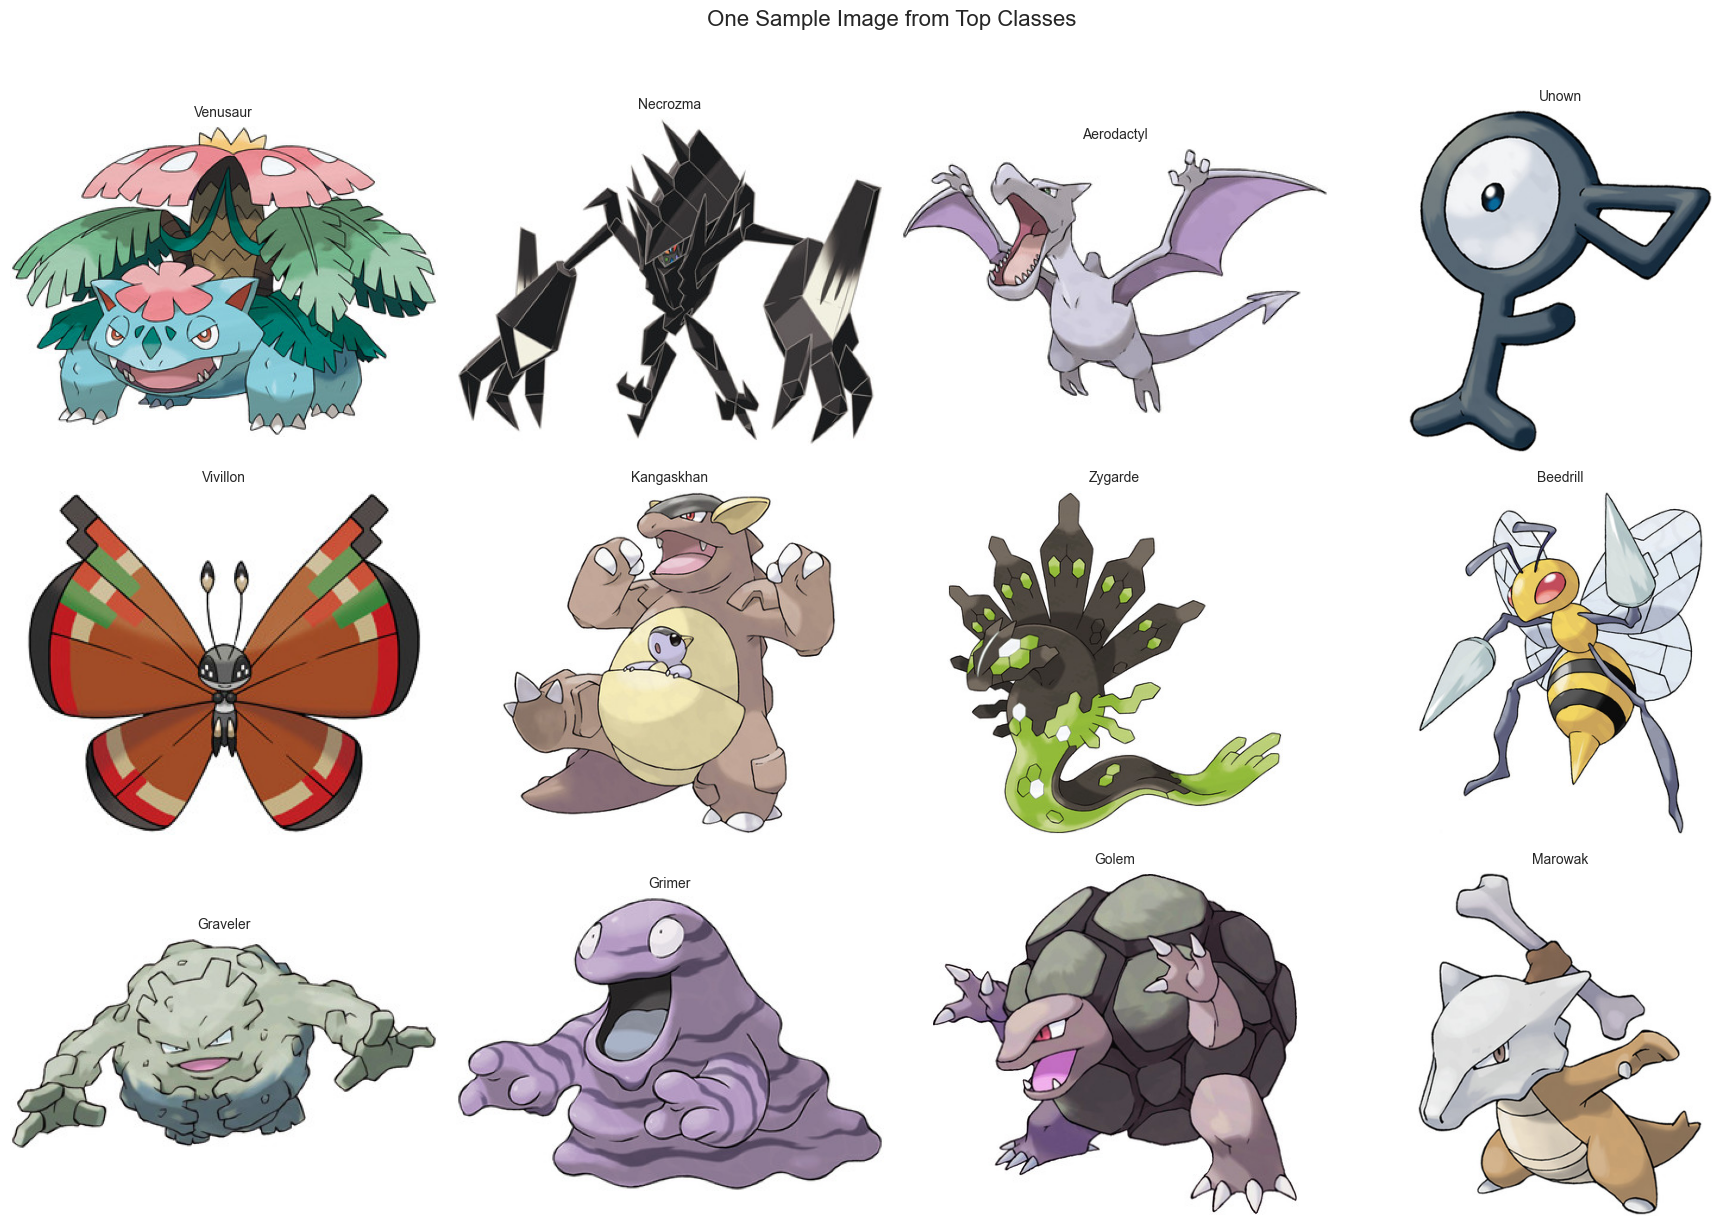

In [66]:
show_classes = class_stats.head(12)["class_name"].tolist()

sample_rows = []
for class_name in show_classes:
    subset = df[df["class_name"] == class_name]
    if not subset.empty:
        sample_rows.append(subset.sample(n=1, random_state=SEED).iloc[0])

gallery_df = pd.DataFrame(sample_rows)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, row in zip(axes, gallery_df.itertuples(index=False)):
    with Image.open(row.file_path) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(row.class_name, fontsize=10)
    ax.axis("off")

for ax in axes[len(gallery_df):]:
    ax.axis("off")

plt.suptitle("One Sample Image from Top Classes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Key Findings

### Key Findings
1. The dataset is highly long-tailed: 898 classes for 2,503 images, and 520 classes have <=2 images.
2. File format consistency is strong in the current run: all images are `.jpg` and decoded as `RGB` (2,503/2,503).
3. Missing-values audit on critical metadata columns is clean (0 rows with missing critical fields).
4. Outlier rates are low for file size and megapixels, while aspect-ratio outliers are more noticeable and should be normalized in preprocessing.
5. Exact-duplicate impact is low globally but meaningful locally: 1 duplicate hash group, 2 images in duplicate groups (0.08%), 1 redundant image (0.04%).
6. The duplicate case is cross-class (`Appletun` and `Flapple`), so potential label ambiguity/noise exists for visually similar classes.
7. Split coverage risk is high for rare classes: 659 classes have no validation sample and 520 classes have <=1 training sample under the current simulation.
8. Duplicate-hash leakage across train/val/test is 0 groups in this simulation, but group-aware splitting is still required for production safety.